In [1]:
import os
import uproot
import numpy as np

def load_root_file(file_path, branches=None, print_branches=False):
    all_branches = {}
    with uproot.open(file_path) as file:
        tree = file["tree"]
        # Load all ROOT branches into array if not specified
        if branches is None:
            branches = tree.keys()
        # Option to print the branch names
        if print_branches:
            print("Branches:", tree.keys())
        # Each branch is added to the dictionary
        for branch in branches:
            try:
                all_branches[branch] = (tree[branch].array(library="np"))
            except uproot.KeyInFileError as e:
                print(f"KeyInFileError: {e}")
        # Number of events in file
        all_branches['event'] = tree.num_entries
    return all_branches

branches_list = [
    # Core T3 properties from TripletsSoA
    't3_betaIn',
    't3_centerX',
    't3_centerY',
    't3_radius',
    't3_partOfPT5',
    't3_partOfT5',
    't3_partOfPT3',
    't3_layer_binary',
    't3_pMatched',
    't3_matched_simIdx',
    't3_sim_vxy',
    't3_sim_vz'
]

# Hit-dependent branches
suffixes = ['r', 'z', 'eta', 'phi', 'layer']
branches_list += [f't3_hit_{i}_{suffix}' for i in [0, 1, 2, 3, 4, 5] for suffix in suffixes]

file_path = "600_t3_dnn_relval_fix.root"
branches = load_root_file(file_path, branches_list)

In [2]:
z_max = np.max([np.max(event) for event in branches[f't3_hit_3_z']])
r_max = np.max([np.max(event) for event in branches[f't3_hit_3_r']])
eta_max = 2.5
phi_max = np.pi

print(f'Z max: {z_max}, R max: {r_max}, Eta max: {eta_max}')

def delta_phi(phi1, phi2):
    delta = phi1 - phi2
    # Adjust delta to be within the range [-pi, pi]
    if delta > np.pi:
        delta -= 2 * np.pi
    elif delta < -np.pi:
        delta += 2 * np.pi
    return delta

Z max: 224.14950561523438, R max: 98.93299102783203, Eta max: 2.5


In [3]:
features_list = []
eta_list = []

for event in range(branches['event']):
    num_elements = len(branches['t3_betaIn'][event])
    for i in range(num_elements):
        features_iter = []
        eta_iter = []
        
        # Get properties for the 3 selected hits (0, 2, 4)
        eta1 = np.abs(branches['t3_hit_0_eta'][event][i])
        eta3 = np.abs(branches['t3_hit_2_eta'][event][i])
        eta5 = np.abs(branches['t3_hit_4_eta'][event][i])

        phi1 = branches['t3_hit_0_phi'][event][i]
        phi3 = branches['t3_hit_2_phi'][event][i]
        phi5 = branches['t3_hit_4_phi'][event][i]

        z1 = np.abs(branches['t3_hit_0_z'][event][i])
        z3 = np.abs(branches['t3_hit_2_z'][event][i])
        z5 = np.abs(branches['t3_hit_4_z'][event][i])

        r1 = branches['t3_hit_0_r'][event][i]
        r3 = branches['t3_hit_2_r'][event][i]
        r5 = branches['t3_hit_4_r'][event][i]

        # T3-specific properties
        radius = branches['t3_radius'][event][i]
        centerX = branches['t3_centerX'][event][i]
        centerY = branches['t3_centerY'][event][i]
        betaIn = branches['t3_betaIn'][event][i]

        features_iter = [
            eta1 / eta_max,                      # First hit eta, normalized
            np.abs(phi1) / phi_max,              # First hit phi, normalized
            z1 / z_max,                          # First hit z, normalized
            r1 / r_max,                          # First hit r, normalized

            eta3 - eta1,                         # Difference in eta between hit 3 and 1
            delta_phi(phi3, phi1) / phi_max,     # Difference in phi between hit 3 and 1
            (z3 - z1) / z_max,                   # Difference in z between hit 3 and 1, normalized
            (r3 - r1) / r_max,                   # Difference in r between hit 3 and 1, normalized

            eta5 - eta3,                         # Difference in eta between hit 5 and 3
            delta_phi(phi5, phi3) / phi_max,     # Difference in phi between hit 5 and 3
            (z5 - z3) / z_max,                   # Difference in z between hit 5 and 3, normalized
            (r5 - r3) / r_max,                   # Difference in r between hit 5 and 3, normalized

            np.log10(radius),                    # T3's circle radius
            betaIn                               # Beta angle of inner segment
        ]

        eta_iter.extend([eta1])  # Use first hit eta for cut thresholds
        features_list.append(features_iter)
        eta_list.append(eta_iter)

features = np.array(features_list).T
eta_list = np.array(eta_list).T

In [4]:
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Stack features and handle NaN/Inf as before
input_features_numpy = np.stack(features, axis=-1)
mask = ~np.isnan(input_features_numpy) & ~np.isinf(input_features_numpy)
filtered_input_features_numpy = input_features_numpy[np.all(mask, axis=1)]
t3_isFake_filtered = (np.concatenate(branches['t3_pMatched']) < 0.75)[np.all(mask, axis=1)]
t3_sim_vxy_filtered = np.concatenate(branches['t3_sim_vxy'])[np.all(mask, axis=1)]

# Convert to PyTorch tensor
input_features_tensor = torch.tensor(filtered_input_features_numpy, dtype=torch.float32)

In [5]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create multi-class labels
def create_multiclass_labels(t3_isFake, t3_sim_vxy, displacement_threshold=0.1):
    num_samples = len(t3_isFake)
    labels = torch.zeros((num_samples, 3))
    
    # Fake tracks (class 0)
    fake_mask = t3_isFake
    labels[fake_mask, 0] = 1
    
    # Real tracks
    real_mask = ~fake_mask
    
    # Split real tracks into prompt (class 1) and displaced (class 2)
    prompt_mask = (t3_sim_vxy <= displacement_threshold) & real_mask
    displaced_mask = (t3_sim_vxy > displacement_threshold) & real_mask
    
    labels[prompt_mask, 1] = 1
    labels[displaced_mask, 2] = 1
    
    return labels

# Create labels tensor
labels_tensor = create_multiclass_labels(
    t3_isFake_filtered,
    t3_sim_vxy_filtered
)

# Neural network for multi-class classification
class MultiClassNeuralNetwork(nn.Module):
    def __init__(self):
        super(MultiClassNeuralNetwork, self).__init__()
        self.layer1 = nn.Linear(input_features_numpy.shape[1], 32)
        self.layer2 = nn.Linear(32, 32)
        self.output_layer = nn.Linear(32, 3)
        
    def forward(self, x):
        x = self.layer1(x)
        x = nn.ReLU()(x)
        x = self.layer2(x)
        x = nn.ReLU()(x)
        x = self.output_layer(x)
        return nn.functional.softmax(x, dim=1)

# Weighted loss function for multi-class
class WeightedCrossEntropyLoss(nn.Module):
    def __init__(self):
        super(WeightedCrossEntropyLoss, self).__init__()
        
    def forward(self, outputs, targets, weights):
        eps = 1e-7
        log_probs = torch.log(outputs + eps)
        losses = -weights * torch.sum(targets * log_probs, dim=1)
        return losses.mean()

# Calculate class weights
def calculate_class_weights(labels):
    class_counts = torch.sum(labels, dim=0)
    total_samples = len(labels)
    class_weights = total_samples / (3 * class_counts)  # Normalize across 3 classes
    
    sample_weights = torch.zeros(len(labels))
    for i in range(3):
        sample_weights[labels[:, i] == 1] = class_weights[i]
    
    return sample_weights

# Print initial dataset size
print(f"Initial dataset size: {len(labels_tensor)}")

# Calculate sample weights
sample_weights = calculate_class_weights(labels_tensor)

# Remove rows with NaN and update everything accordingly
nan_mask = torch.isnan(input_features_tensor).any(dim=1)
filtered_inputs = input_features_tensor[~nan_mask]
filtered_labels = labels_tensor[~nan_mask]
filtered_weights = sample_weights[~nan_mask]

# Print class distribution
class_counts = torch.sum(filtered_labels, dim=0)
print(f"Class distribution - Fake: {class_counts[0]}, Prompt: {class_counts[1]}, Displaced: {class_counts[2]}")

# Create dataset with weights
dataset = TensorDataset(filtered_inputs, filtered_labels, filtered_weights)

# Split into train and test sets
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=10, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, num_workers=10, pin_memory=True)

# Initialize model and optimizer
model = MultiClassNeuralNetwork().to(device)
loss_function = WeightedCrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.0025)

def evaluate_loss(loader):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for inputs, targets, weights in loader:
            inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)
            outputs = model(inputs)
            loss = loss_function(outputs, targets, weights)
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches

# Training loop
num_epochs = 1000
train_loss_log = []
test_loss_log = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    num_batches = 0
    
    for inputs, targets, weights in train_loader:
        inputs, targets, weights = inputs.to(device), targets.to(device), weights.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = loss_function(outputs, targets, weights)
        epoch_loss += loss.item()
        num_batches += 1
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate average losses
    train_loss = epoch_loss / num_batches
    test_loss = evaluate_loss(test_loader)
    
    train_loss_log.append(train_loss)
    test_loss_log.append(test_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Using device: cuda
Initial dataset size: 55072926
Class distribution - Fake: 49829032.0, Prompt: 4472777.0, Displaced: 771119.0
Epoch [1/1000], Train Loss: 0.6168, Test Loss: 0.5807
Epoch [2/1000], Train Loss: 0.5716, Test Loss: 0.5690
Epoch [3/1000], Train Loss: 0.5623, Test Loss: 0.5678
Epoch [4/1000], Train Loss: 0.5577, Test Loss: 0.5441
Epoch [5/1000], Train Loss: 0.5543, Test Loss: 0.5445
Epoch [6/1000], Train Loss: 0.5515, Test Loss: 0.5613
Epoch [7/1000], Train Loss: 0.5494, Test Loss: 0.5392
Epoch [8/1000], Train Loss: 0.5478, Test Loss: 0.5394
Epoch [9/1000], Train Loss: 0.5463, Test Loss: 0.5391
Epoch [10/1000], Train Loss: 0.5452, Test Loss: 0.5456
Epoch [11/1000], Train Loss: 0.5441, Test Loss: 0.5542
Epoch [12/1000], Train Loss: 0.5431, Test Loss: 0.5351
Epoch [13/1000], Train Loss: 0.5422, Test Loss: 0.5657
Epoch [14/1000], Train Loss: 0.5414, Test Loss: 0.5410
Epoch [15/1000], Train Loss: 0.5408, Test Loss: 0.5350
Epoch [16/1000], Train Loss: 0.5399, Test Loss: 0.5384
E

Exception ignored in: <function _releaseLock at 0x7fa1e75befc0>
Traceback (most recent call last):
  File "/mnt/data1/gsn27/miniconda/envs/analysisenv/lib/python3.11/logging/__init__.py", line 237, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


KeyboardInterrupt: 

In [6]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Convert tensors to numpy for simplicity if you want to manipulate them outside of PyTorch
input_features_np = input_features_tensor.numpy()
labels_np = torch.argmax(labels_tensor, dim=1).numpy()  # Convert one-hot to class indices

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def model_accuracy(features, labels, model):
    """
    Compute accuracy for a multi-class classification model
    that outputs probabilities of size [batch_size, num_classes].
    """
    model.eval()  # Set the model to evaluation mode
    
    # Move the features and labels to the correct device
    inputs = features.to(device)
    labels = labels.to(device)
    
    with torch.no_grad():
        outputs = model(inputs)  # shape: [batch_size, num_classes]
        # For multi-class, the predicted class is argmax of the probabilities
        predicted = torch.argmax(outputs, dim=1)
        # Convert one-hot encoded labels to class indices if needed
        if len(labels.shape) > 1:
            labels = torch.argmax(labels, dim=1)
        # Compute mean accuracy
        accuracy = (predicted == labels).float().mean().item()
    
    return accuracy

# Compute baseline accuracy
baseline_accuracy = model_accuracy(input_features_tensor, labels_tensor, model)
print(f"Baseline accuracy: {baseline_accuracy:.4f}")

# Initialize array to store feature importances
feature_importances = np.zeros(input_features_tensor.shape[1])

# Iterate over each feature for permutation importance
for i in range(input_features_tensor.shape[1]):
    # Create a copy of the original features
    permuted_features = input_features_tensor.clone()
    
    # Permute feature i across all examples
    # We do this by shuffling the rows for that specific column
    permuted_features[:, i] = permuted_features[torch.randperm(permuted_features.size(0)), i]
    
    # Compute accuracy after permutation
    permuted_accuracy = model_accuracy(permuted_features, labels_tensor, model)
    
    # The drop in accuracy is used as a measure of feature importance
    feature_importances[i] = baseline_accuracy - permuted_accuracy

# Sort features by descending importance
important_features_indices = np.argsort(feature_importances)[::-1]
important_features_scores = np.sort(feature_importances)[::-1]

# Print out results
print("\nFeature importances:")
for idx, score in zip(important_features_indices, important_features_scores):
    print(f"Feature {idx} importance: {score:.4f}")

Baseline accuracy: 0.8668

Feature importances:
Feature 5 importance: 0.0285
Feature 13 importance: 0.0258
Feature 0 importance: 0.0237
Feature 2 importance: 0.0187
Feature 9 importance: 0.0184
Feature 12 importance: 0.0161
Feature 3 importance: 0.0123
Feature 4 importance: 0.0098
Feature 11 importance: 0.0093
Feature 10 importance: 0.0089
Feature 7 importance: 0.0079
Feature 8 importance: 0.0056
Feature 6 importance: 0.0014
Feature 1 importance: -0.0000


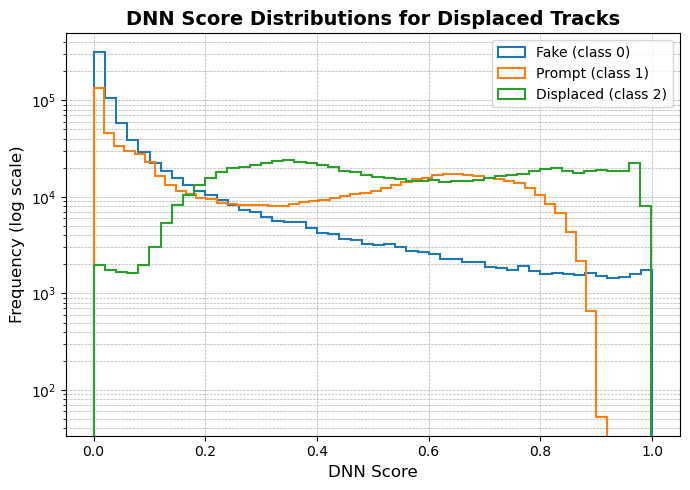

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def model_outputs(inputs, model):
    model.eval()
    with torch.no_grad():
        outputs = model(inputs.to(device))  # shape [N, 3]
        # Convert to probabilities if necessary:
        # outputs = torch.softmax(outputs, dim=1)
    return outputs.cpu().numpy()

# 1) Get the model outputs
probabilities = model_outputs(filtered_inputs, model)  # [N, 3]

# 2) Identify the subset of displaced tracks
displaced_mask = np.concatenate(branches['t3_sim_vxy'])[~nan_mask] > 0.1
displaced_predictions = probabilities[displaced_mask]  # [N_displaced, 3]

# 3) Plot the three distributions on one figure
class_labels = ["Fake (class 0)", "Prompt (class 1)", "Displaced (class 2)"]

plt.figure(figsize=(7, 5))
for i, label in enumerate(class_labels):
    plt.hist(displaced_predictions[:, i],
             bins=50,
             histtype='step',
             linewidth=1.5,
             label=label)

plt.yscale('log')
plt.xlabel("DNN Score", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.title("DNN Score Distributions for Displaced Tracks", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [8]:
def print_formatted_weights_biases(weights, biases, layer_name):
    # Print biases
    print(f"ALPAKA_STATIC_ACC_MEM_GLOBAL const float bias_{layer_name}[{len(biases)}] = {{")
    print(", ".join(f"{b:.7f}f" for b in biases) + " };")
    print()

    # Print weights
    print(f"ALPAKA_STATIC_ACC_MEM_GLOBAL const float wgtT_{layer_name}[{len(weights[0])}][{len(weights)}] = {{")
    for row in weights.T:
        formatted_row = ", ".join(f"{w:.7f}f" for w in row)
        print(f"{{ {formatted_row} }},")
    print("};")
    print()

def print_model_weights_biases(model):
    # Make sure the model is in evaluation mode
    model.eval()

    # Iterate through all named modules in the model
    for name, module in model.named_modules():
        # Check if the module is a linear layer
        if isinstance(module, nn.Linear):
            # Get weights and biases
            weights = module.weight.data.cpu().numpy()
            biases = module.bias.data.cpu().numpy()

            # Print formatted weights and biases
            print_formatted_weights_biases(weights, biases, name.replace('.', '_'))

print_model_weights_biases(model)


ALPAKA_STATIC_ACC_MEM_GLOBAL const float bias_layer1[32] = {
-0.2627841f, 0.0059654f, -1.2097707f, 0.0577601f, -7.3805332f, -0.2212038f, -0.0723716f, -0.0273308f, 5.1590590f, -1.3129746f, -0.7206987f, 3.6706116f, -4.4685054f, 0.8050013f, -0.0133669f, -0.3556877f, -3.3106117f, -0.0752867f, 1.0860413f, -3.9797719f, 0.0039556f, -7.6881080f, -2.0296855f, -0.2235096f, -20.8147888f, -0.4787821f, 6.8188891f, 0.8549373f, -0.2545580f, -0.1812256f, -0.0329677f, 0.2457884f };

ALPAKA_STATIC_ACC_MEM_GLOBAL const float wgtT_layer1[14][32] = {
{ 0.2006950f, 0.0082387f, -0.3748818f, 0.2377538f, 6.7150211f, -0.0977085f, 0.0458572f, 0.0045279f, -0.5217038f, 0.5697329f, 2.5272076f, 5.8253336f, 4.3396115f, 0.4371617f, -0.2997586f, 5.0937381f, -1.7397610f, 0.0161637f, -1.9346550f, 3.7016492f, -0.1427350f, 4.2522988f, 1.0191960f, -0.2436244f, 3.0223954f, 0.1028274f, -1.0745809f, 8.6680336f, -0.1366939f, -0.1972376f, -0.0069632f, -0.2492642f },
{ 0.1758677f, -0.1760893f, 0.0357523f, -0.2341647f, -0.0856097f

In [9]:
# Ensure input_features_tensor is moved to the appropriate device
input_features_tensor = input_features_tensor.to(device)

# Make predictions
with torch.no_grad():
    model.eval()
    outputs = model(input_features_tensor)
    predictions = outputs.squeeze().cpu().numpy()

full_tracks = (np.concatenate(branches['t3_pMatched']) > 0.95)

t3_pt = np.concatenate(branches['t3_radius']) * 2 * (2.99792458e-3 * 3.8) / 2

Eta bin 0.00-0.25: 9409714 fakes, 313231 true Prompt
Eta bin 0.25-0.50: 9242595 fakes, 323051 true Prompt
Eta bin 0.50-0.75: 7849380 fakes, 410185 true Prompt
Eta bin 0.75-1.00: 4293980 fakes, 322065 true Prompt
Eta bin 1.00-1.25: 4343023 fakes, 374215 true Prompt
Eta bin 1.25-1.50: 2725728 fakes, 351420 true Prompt
Eta bin 1.50-1.75: 1368266 fakes, 425819 true Prompt
Eta bin 1.75-2.00: 1413754 fakes, 467604 true Prompt
Eta bin 2.00-2.25: 448439 fakes, 419450 true Prompt
Eta bin 2.25-2.50: 124212 fakes, 247704 true Prompt


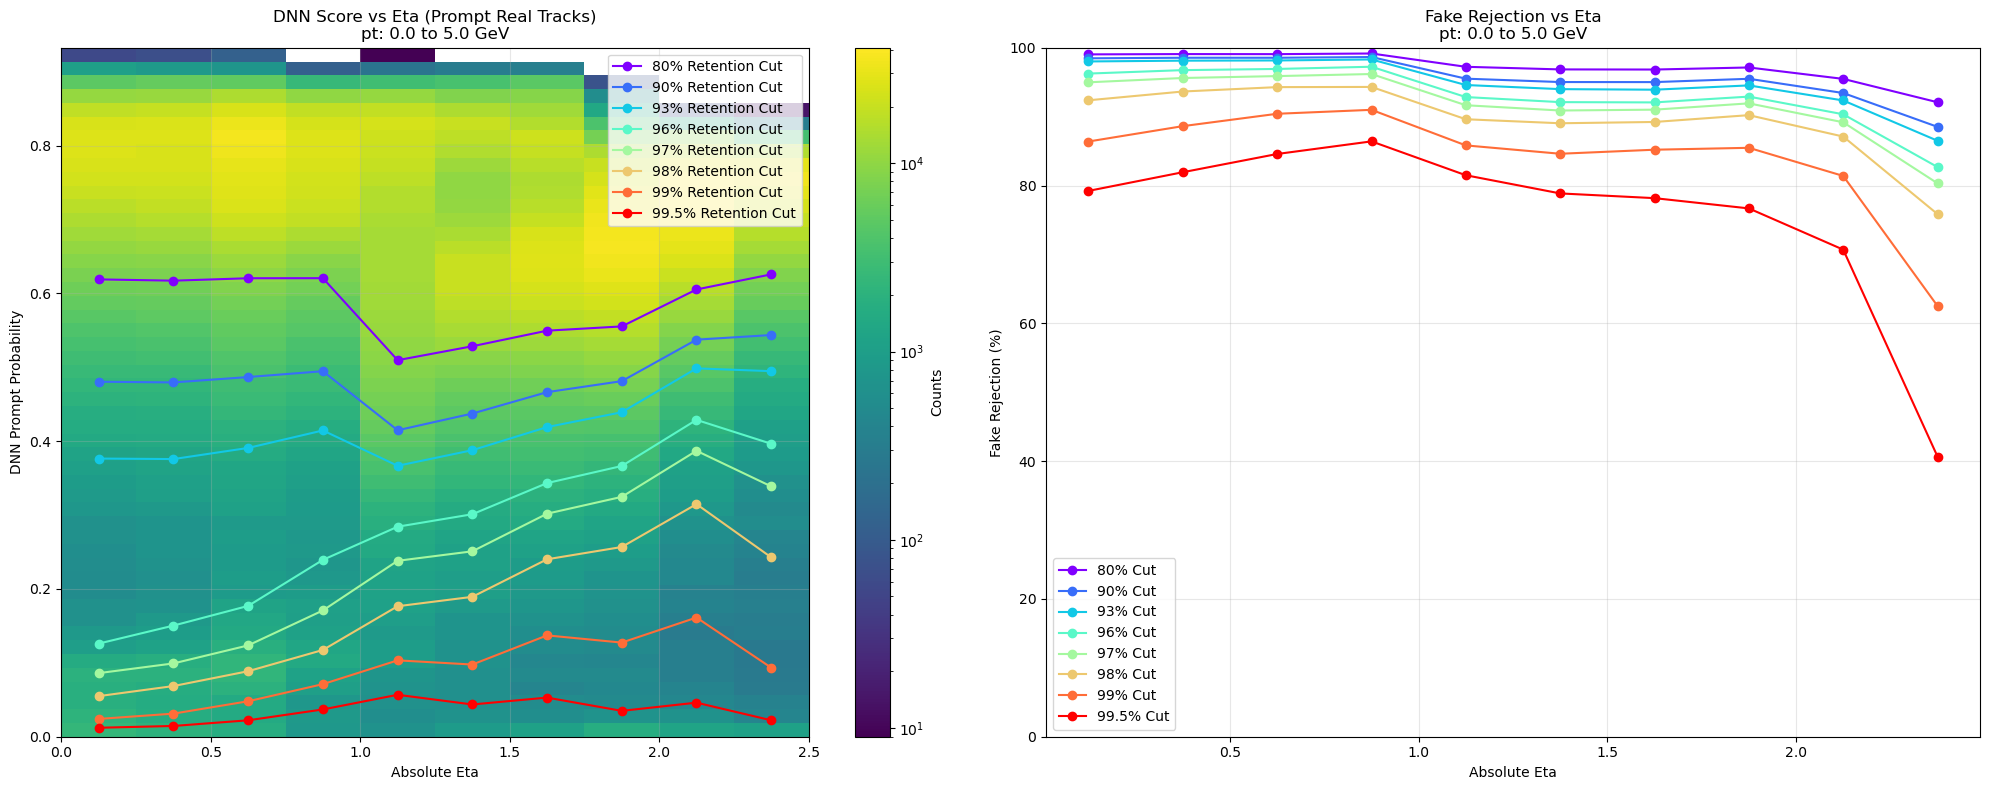


Prompt tracks, pt: 0.0 to 5.0 GeV
Number of true prompt tracks: 3654744
Number of fake tracks in pt bin: 41219091

80% Retention Cut Values: {0.6190, 0.6173, 0.6206, 0.6207, 0.5097, 0.5285, 0.5496, 0.5554, 0.6054, 0.6258} Mean: 0.5852
80% Cut Fake Rejections: {99.0, 99.1, 99.1, 99.2, 97.2, 96.9, 96.8, 97.1, 95.5, 92.1} Mean: 97.2%

90% Retention Cut Values: {0.4805, 0.4796, 0.4868, 0.4948, 0.4148, 0.4374, 0.4664, 0.4813, 0.5375, 0.5437} Mean: 0.4823
90% Cut Fake Rejections: {98.5, 98.5, 98.5, 98.7, 95.5, 95.0, 95.0, 95.5, 93.4, 88.5} Mean: 95.7%

93% Retention Cut Values: {0.3765, 0.3758, 0.3909, 0.4146, 0.3667, 0.3879, 0.4191, 0.4392, 0.4986, 0.4948} Mean: 0.4164
93% Cut Fake Rejections: {98.0, 98.1, 98.2, 98.3, 94.6, 94.0, 93.9, 94.5, 92.3, 86.5} Mean: 94.8%

96% Retention Cut Values: {0.1261, 0.1504, 0.1771, 0.2394, 0.2843, 0.3011, 0.3433, 0.3664, 0.4289, 0.3965} Mean: 0.2814
96% Cut Fake Rejections: {96.3, 96.7, 96.9, 97.2, 92.8, 92.1, 92.1, 92.9, 90.3, 82.7} Mean: 93.0%

97% Rete

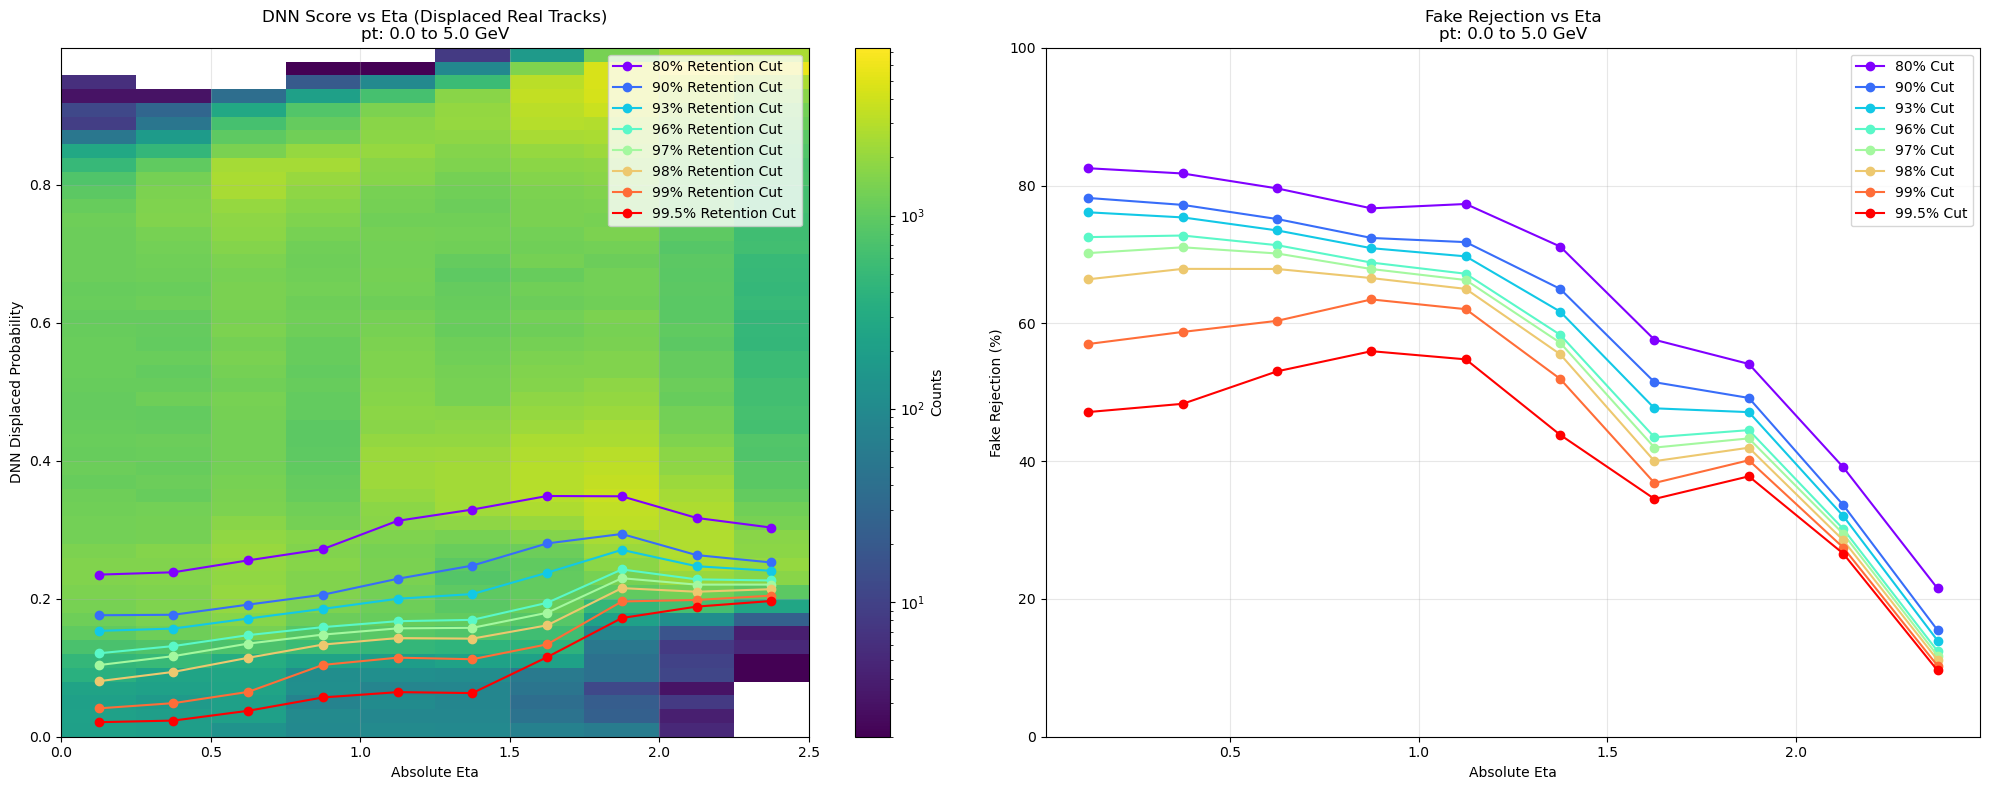


Displaced tracks, pt: 0.0 to 5.0 GeV
Number of true displaced tracks: 611820
Number of fake tracks in pt bin: 41219091

80% Retention Cut Values: {0.2350, 0.2384, 0.2557, 0.2719, 0.3130, 0.3293, 0.3489, 0.3485, 0.3172, 0.3032} Mean: 0.2961
80% Cut Fake Rejections: {82.5, 81.7, 79.6, 76.7, 77.3, 71.1, 57.6, 54.1, 39.1, 21.5} Mean: 64.1%

90% Retention Cut Values: {0.1761, 0.1768, 0.1915, 0.2058, 0.2290, 0.2481, 0.2802, 0.2939, 0.2633, 0.2526} Mean: 0.2317
90% Cut Fake Rejections: {78.2, 77.2, 75.1, 72.4, 71.8, 65.0, 51.5, 49.2, 33.6, 15.5} Mean: 58.9%

93% Retention Cut Values: {0.1534, 0.1568, 0.1713, 0.1853, 0.2000, 0.2068, 0.2378, 0.2708, 0.2472, 0.2405} Mean: 0.207
93% Cut Fake Rejections: {76.1, 75.4, 73.5, 70.9, 69.7, 61.7, 47.7, 47.1, 32.0, 14.0} Mean: 56.8%

96% Retention Cut Values: {0.1209, 0.1314, 0.1473, 0.1589, 0.1675, 0.1694, 0.1941, 0.2425, 0.2281, 0.2265} Mean: 0.1787
96% Cut Fake Rejections: {72.5, 72.7, 71.3, 68.8, 67.2, 58.3, 43.5, 44.5, 30.2, 12.4} Mean: 54.2%

97% 

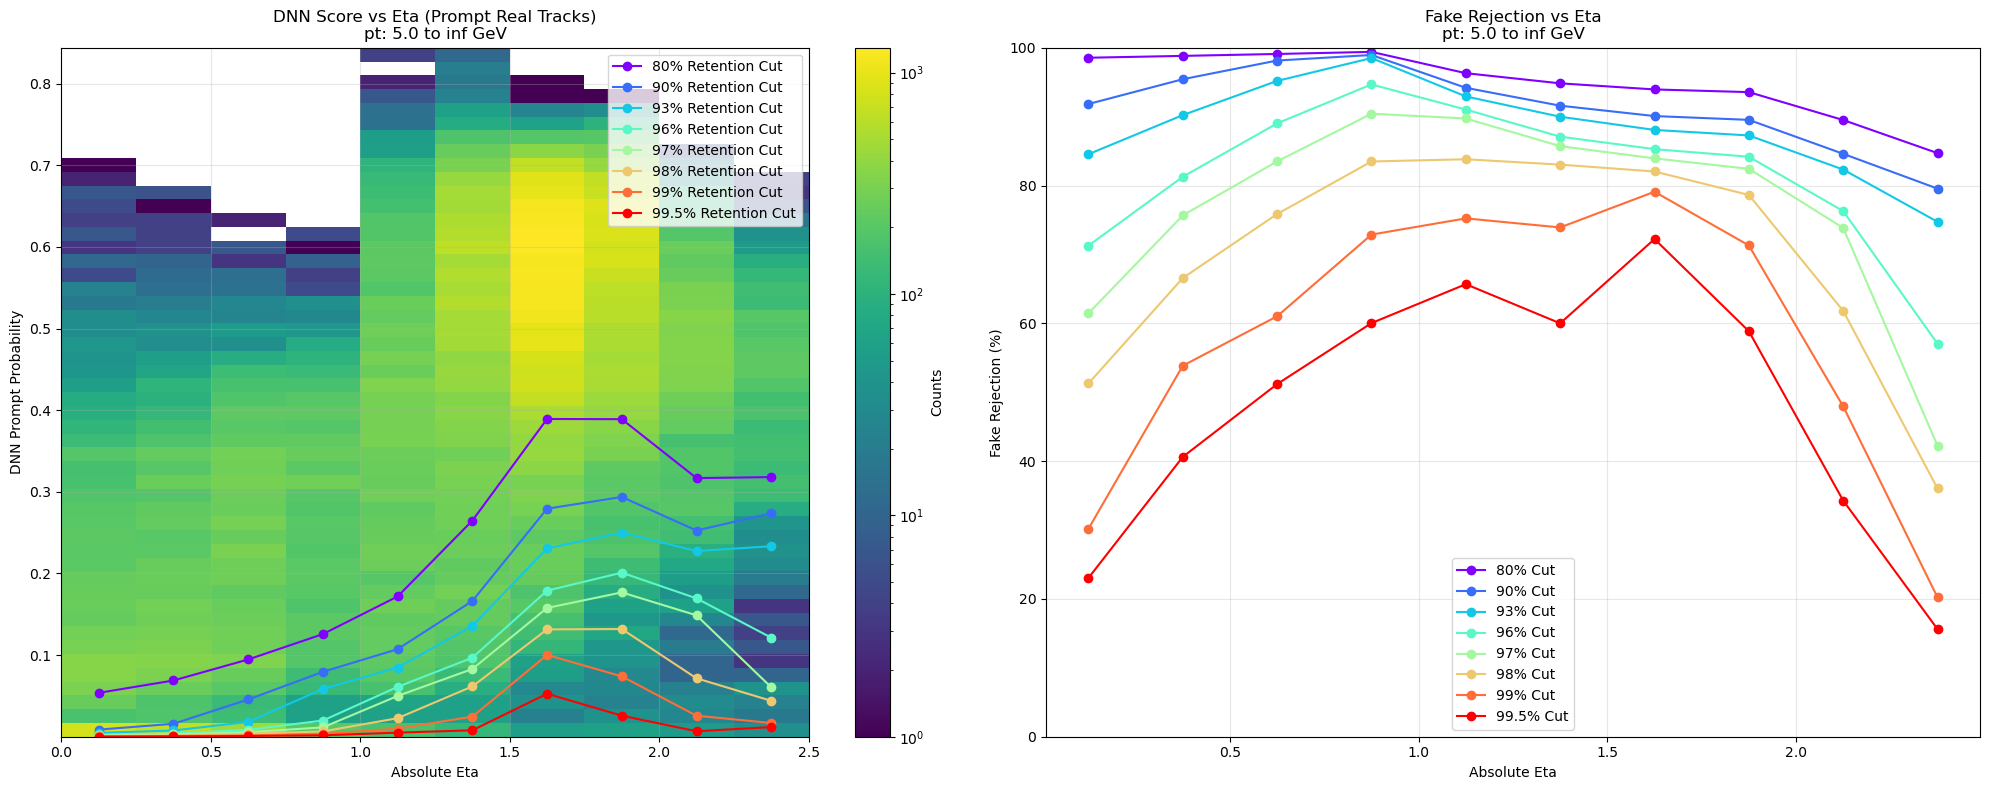


Prompt tracks, pt: 5.0 to inf GeV
Number of true prompt tracks: 99138
Number of fake tracks in pt bin: 8609939

80% Retention Cut Values: {0.0537, 0.0689, 0.0946, 0.1257, 0.1718, 0.2647, 0.3892, 0.3890, 0.3168, 0.3181} Mean: 0.2193
80% Cut Fake Rejections: {98.5, 98.8, 99.1, 99.4, 96.3, 94.8, 93.9, 93.6, 89.5, 84.7} Mean: 94.9%

90% Retention Cut Values: {0.0087, 0.0158, 0.0456, 0.0795, 0.1072, 0.1662, 0.2793, 0.2937, 0.2526, 0.2738} Mean: 0.1522
90% Cut Fake Rejections: {91.8, 95.4, 98.1, 98.9, 94.2, 91.6, 90.1, 89.5, 84.6, 79.6} Mean: 91.4%

93% Retention Cut Values: {0.0047, 0.0076, 0.0182, 0.0585, 0.0847, 0.1358, 0.2307, 0.2501, 0.2275, 0.2333} Mean: 0.1251
93% Cut Fake Rejections: {84.5, 90.2, 95.2, 98.5, 92.9, 90.0, 88.1, 87.3, 82.3, 74.7} Mean: 88.4%

96% Retention Cut Values: {0.0024, 0.0039, 0.0085, 0.0198, 0.0610, 0.0968, 0.1789, 0.2010, 0.1695, 0.1213} Mean: 0.0863
96% Cut Fake Rejections: {71.3, 81.3, 89.0, 94.7, 91.0, 87.1, 85.3, 84.2, 76.3, 57.0} Mean: 81.7%

97% Retenti

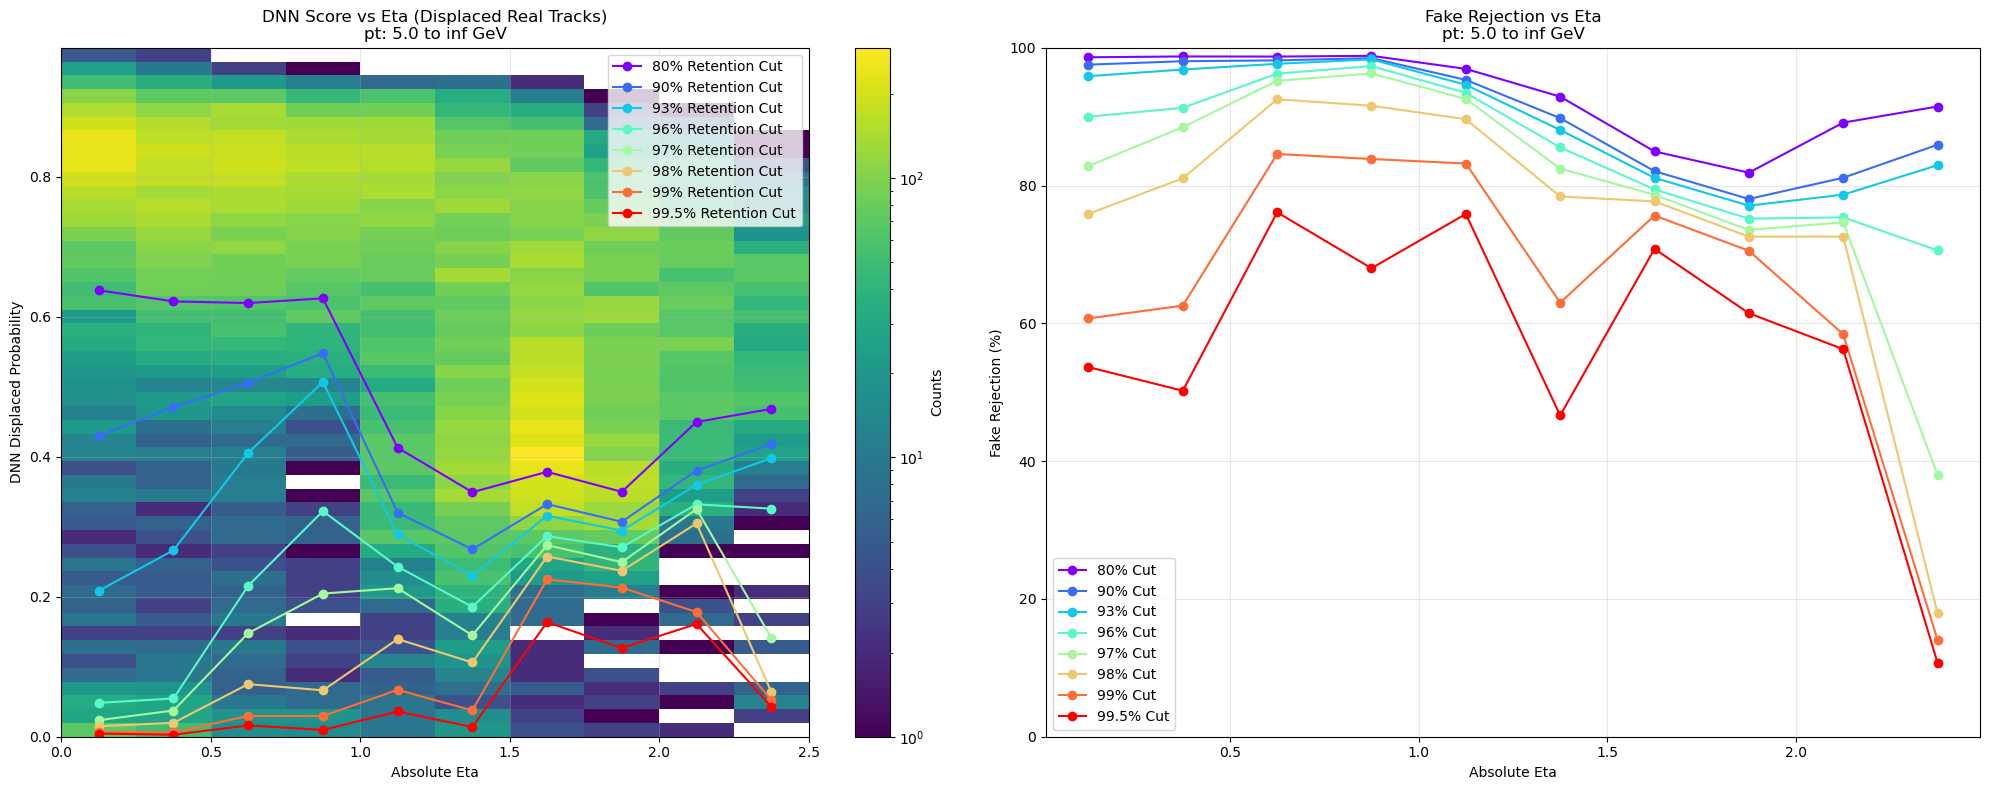


Displaced tracks, pt: 5.0 to inf GeV
Number of true displaced tracks: 26375
Number of fake tracks in pt bin: 8609939

80% Retention Cut Values: {0.6381, 0.6222, 0.6198, 0.6265, 0.4131, 0.3495, 0.3786, 0.3500, 0.4499, 0.4685} Mean: 0.4916
80% Cut Fake Rejections: {98.6, 98.7, 98.7, 98.8, 96.9, 92.9, 84.9, 81.9, 89.1, 91.5} Mean: 93.2%

90% Retention Cut Values: {0.4300, 0.4712, 0.5058, 0.5481, 0.3202, 0.2678, 0.3324, 0.3072, 0.3804, 0.4181} Mean: 0.3981
90% Cut Fake Rejections: {97.5, 98.0, 98.2, 98.5, 95.3, 89.8, 82.1, 78.0, 81.1, 85.9} Mean: 90.5%

93% Retention Cut Values: {0.2087, 0.2664, 0.4058, 0.5070, 0.2891, 0.2303, 0.3158, 0.2947, 0.3600, 0.3981} Mean: 0.3276
93% Cut Fake Rejections: {95.9, 96.8, 97.7, 98.3, 94.6, 88.1, 81.1, 77.1, 78.7, 82.9} Mean: 89.1%

96% Retention Cut Values: {0.0484, 0.0547, 0.2158, 0.3224, 0.2430, 0.1856, 0.2867, 0.2708, 0.3322, 0.3260} Mean: 0.2286
96% Cut Fake Rejections: {90.0, 91.3, 96.2, 97.3, 93.5, 85.5, 79.4, 75.2, 75.4, 70.6} Mean: 85.4%

97% R

In [12]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import torch

# Ensure input_features_tensor is on the right device
input_features_tensor = input_features_tensor.to(device)

# Get model predictions
with torch.no_grad():
    model.eval()
    outputs = model(input_features_tensor)
    predictions = outputs.cpu().numpy()  # Shape will be [n_samples, 3]

# Get track information
t3_pt = np.concatenate(branches['t3_radius']) * 2 * (2.99792458e-3 * 3.8) / 2

def plot_for_pt_bin(pt_min, pt_max, percentiles, eta_bin_edges, t3_pt, predictions, t3_sim_vxy, eta_list):
    """
    Calculate and plot cut values for specified percentiles in a given pt bin, separately for prompt and displaced tracks
    """
    # Filter data based on pt bin
    pt_mask = (t3_pt > pt_min) & (t3_pt <= pt_max)
    
    # Get absolute eta values for all tracks in pt bin
    abs_eta = np.abs(eta_list[0][pt_mask])
    
    # Get predictions for all tracks in pt bin
    pred_filtered = predictions[pt_mask]
    
    # Get track types using pMatched and t3_sim_vxy
    matched = (np.concatenate(branches['t3_pMatched']) > 0.95)[pt_mask]
    fake_tracks = (np.concatenate(branches['t3_pMatched']) < 0.75)[pt_mask]
    true_displaced = (t3_sim_vxy[pt_mask] > 0.1) & matched
    true_prompt = ~(t3_sim_vxy[pt_mask] > 0.1) & matched
    
    # Separate plots for prompt and displaced tracks
    for track_type, true_mask, pred_idx, title_suffix in [
        ("Prompt", true_prompt, 1, "Prompt Real Tracks"),
        ("Displaced", true_displaced, 2, "Displaced Real Tracks")
    ]:
        # Dictionaries to store values
        cut_values = {p: [] for p in percentiles}
        fake_rejections = {p: [] for p in percentiles}
        
        # Get probabilities for this class
        probs = pred_filtered[:, pred_idx]
        
        # Create two side-by-side plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        
        # Plot probability distribution (only for true tracks of this type)
        h = ax1.hist2d(abs_eta[true_mask], 
                      probs[true_mask], 
                      bins=[eta_bin_edges, 50], 
                      norm=LogNorm())
        plt.colorbar(h[3], ax=ax1, label='Counts')
        
        # For each eta bin
        bin_centers = []
        for i in range(len(eta_bin_edges) - 1):
            eta_min, eta_max = eta_bin_edges[i], eta_bin_edges[i+1]
            bin_center = (eta_min + eta_max) / 2
            bin_centers.append(bin_center)
            
            # Get tracks in this eta bin
            eta_mask = (abs_eta >= eta_min) & (abs_eta < eta_max)
            
            # True tracks of this type in this bin
            true_type_mask = eta_mask & true_mask
            # Fake tracks in this bin
            fake_mask = eta_mask & fake_tracks
            
            print(f"Eta bin {eta_min:.2f}-{eta_max:.2f}: {np.sum(fake_mask)} fakes, {np.sum(true_type_mask)} true {track_type}")
            
            if np.sum(true_type_mask) > 0:  # If we have true tracks in this bin
                for percentile in percentiles:
                    # Calculate cut value to keep desired percentage of true tracks
                    cut_value = np.percentile(probs[true_type_mask], 100 - percentile)
                    cut_values[percentile].append(cut_value)
                    
                    # Calculate fake rejection for this cut
                    if np.sum(fake_mask) > 0:
                        fake_rej = 100 * np.mean(probs[fake_mask] < cut_value)
                        fake_rejections[percentile].append(fake_rej)
                    else:
                        fake_rejections[percentile].append(np.nan)
            else:
                for percentile in percentiles:
                    cut_values[percentile].append(np.nan)
                    fake_rejections[percentile].append(np.nan)
        
        # Plot cut values and fake rejections
        colors = plt.cm.rainbow(np.linspace(0, 1, len(percentiles)))
        bin_centers = np.array(bin_centers)
        
        for (percentile, color) in zip(percentiles, colors):
            values = np.array(cut_values[percentile])
            mask = ~np.isnan(values)
            if np.any(mask):
                # Plot cut values
                ax1.plot(bin_centers[mask], values[mask], '-', color=color, marker='o',
                        label=f'{percentile}% Retention Cut')
                # Plot fake rejections
                rej_values = np.array(fake_rejections[percentile])
                ax2.plot(bin_centers[mask], rej_values[mask], '-', color=color, marker='o',
                        label=f'{percentile}% Cut')
        
        # Set plot labels and titles
        ax1.set_xlabel("Absolute Eta")
        ax1.set_ylabel(f"DNN {track_type} Probability")
        ax1.set_title(f"DNN Score vs Eta ({title_suffix})\npt: {pt_min:.1f} to {pt_max:.1f} GeV")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.set_xlabel("Absolute Eta")
        ax2.set_ylabel("Fake Rejection (%)")
        ax2.set_title(f"Fake Rejection vs Eta\npt: {pt_min:.1f} to {pt_max:.1f} GeV")
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_ylim(0, 100)
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\n{track_type} tracks, pt: {pt_min:.1f} to {pt_max:.1f} GeV")
        print(f"Number of true {track_type.lower()} tracks: {np.sum(true_mask)}")
        print(f"Number of fake tracks in pt bin: {np.sum(fake_tracks)}")
        
        for percentile in percentiles:
            print(f"\n{percentile}% Retention Cut Values:",
                  '{' + ', '.join(f"{x:.4f}" if not np.isnan(x) else 'nan' for x in cut_values[percentile]) + '}',
                  f"Mean: {np.round(np.nanmean(cut_values[percentile]), 4)}")
            print(f"{percentile}% Cut Fake Rejections:",
                  '{' + ', '.join(f"{x:.1f}" if not np.isnan(x) else 'nan' for x in fake_rejections[percentile]) + '}',
                  f"Mean: {np.round(np.nanmean(fake_rejections[percentile]), 1)}%")

def analyze_pt_bins(pt_bins, percentiles, eta_bin_edges, t3_pt, predictions, t3_sim_vxy, eta_list):
    """
    Analyze and plot for multiple pt bins and percentiles
    """
    for i in range(len(pt_bins) - 1):
        plot_for_pt_bin(pt_bins[i], pt_bins[i + 1], percentiles, eta_bin_edges,
                       t3_pt, predictions, t3_sim_vxy, eta_list)

# Run the analysis with same parameters as before
percentiles = [80, 90, 93, 96, 97, 98, 99, 99.5]
pt_bins = [0, 5, np.inf]
eta_bin_edges = np.arange(0, 2.75, 0.25)

analyze_pt_bins(
    pt_bins=pt_bins,
    percentiles=percentiles,
    eta_bin_edges=eta_bin_edges,
    t3_pt=t3_pt,
    predictions=predictions,
    t3_sim_vxy=np.concatenate(branches['t3_sim_vxy']),
    eta_list=eta_list
)